# Машинное обучение, ФКН ВШЭ

## Практическое домашнее задание 3.2  Продвинутая генерация признаков

### Общая информация

Дата выдачи: 23.02.2026

Мягкий дедлайн: 12.03.2026 23:59MSK

Жесткий дедлайн: 16.03.2026 23:59MSK

### О задании

В данном задании вы познакомитесь с менее тривиальными подходами для создания новых признаков в табличном машинном обучении. Вам понадобится подумать над тем, зачем мы делаем те или иные преобразования, научиться принимать решения, дающие наилучшие результаты, и узнать, как реализовывать их при помощи библиотек

### Оценивание и штрафы

См. базовую часть

### Формат сдачи
Задания сдаются через систему Anytask. Инвайт можно найти на странице курса. Присылать необходимо ноутбук с выполненным заданием. Сам ноутбук называйте в формате **homework-practice-03-advanced-Username.ipynb**, где Username — ваша фамилия.

### **Введение**

В этой части ноутбука задания посложнее дефолтного фит трансформа. Максимальная оценка за оба — 8 баллов, остальное вы можете получить, если примете участие в соревновании, и всего можете выбить аж 13 из 10. Тут ожидается больше самостоятельности, как от (почти) полноценной рабочей единицы:
- Вы **сами** решаете, что <font color="#cb9255">**хотите**</font> делать. Пункты можно делать частично, можно скипать или сделать часть, **максимум баллов ограничен двумя**. **Посмотрите на все из них**, прежде чем приступать
- Вы **сами** чистите данные, если чуете в них подвох (теперь они далеко не такие няшные)
- Вы **сами** <font color="#f68c9d">**обосновываете**</font> (в голове, если не указано явно), могут они вам вообще помочь или нет (часть пунктов явно сильнее других)

Все прочие пожелания по тому, как строить графики, на чём фиттить, а на чём предиктить, сохраняются, будьте внимательны. Во всех пунктах с 📈 нужно добиться хотя бы минимального улучшения, относительно бейзлайна (того, что вышло в части **base**) чтобы получить балл (даже если улучшение на 0.005)

Ещё раз обратите внимание, что **максимум за advanced часть — 2 балла**, делать всё не нужно, только самое приятное. Мы в вас верим!

ЗАРАНЕЕ извиняюсь, что может вышло немного неаккуратно в этой части: что-то совсем потная была, на блоки жёстко била чтобы ну не пересчитывать лишнее, так как это времени много занимает.

Сделала 4 + 5 + 6.2

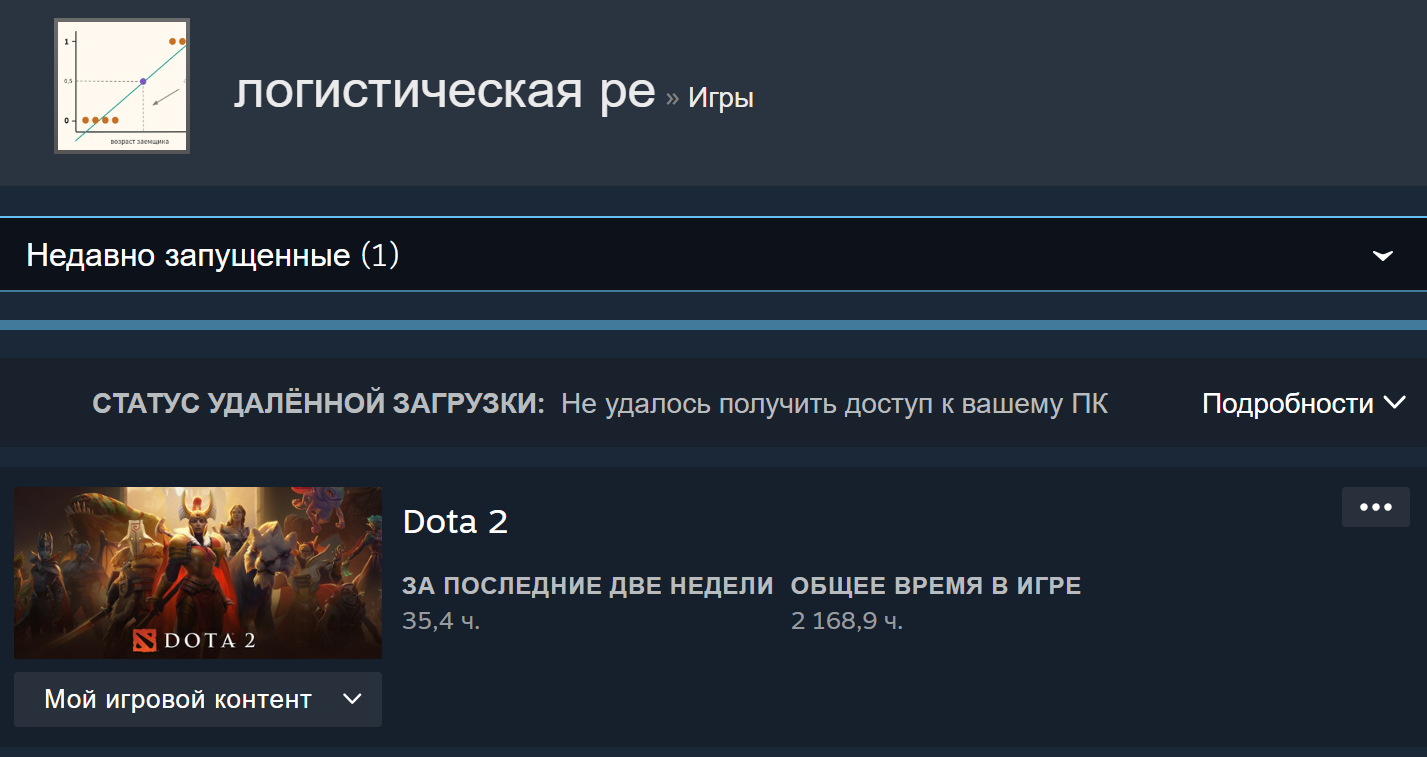

In [ ]:
from sklearn.metrics import roc_auc_score


def gini(y_true, y_score):
    return 2 * roc_auc_score(y_true, y_score) - 1.0

In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit


matches_train = pd.read_csv('matches_train_final (3).csv')
matches_test = pd.read_csv('matches_test_final (2).csv')
all_features = joblib.load('all_features_final.pkl')
best_params = joblib.load('best_params_final.pkl')
final_model = joblib.load('final_model (1).pkl')

matches_train['date'] = pd.to_datetime(matches_train['date'])

matches_train = matches_train.sort_values('date').reset_index(drop=True)
cv_oot = TimeSeriesSplit(n_splits=5)

X = matches_train[all_features]
y = matches_train['radiant_win']

In [ ]:
scores = []
for fold, (train_idx, val_idx) in enumerate(cv_oot.split(matches_train)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    final_model.fit(X_train, y_train)
    pred = final_model.predict_proba(X_val)[:, 1]
    scores.append(gini(y_val, pred))

print(f"Gini в продвинутом: {np.mean(scores)}")

Gini в продвинутом: 0.3094431041513183


In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
import joblib

final_model = LogisticRegression(max_iter=1000, solver='liblinear', C=0.5)
final_model.fit(X_combined, y)

test_pred = final_model.predict_proba(X_combined_test)[:, 1]

original_test = pd.read_csv('matches_df_test.csv')
original_test['radiant_win_prob'] = 0.5
mask = original_test['match_id'].isin(matches_test['match_id'])
original_test.loc[mask, 'radiant_win_prob'] = test_pred

submission = pd.DataFrame({
    'ID': original_test['match_id'],
    'Value': original_test['radiant_win_prob']
})
submission.to_csv('submission.csv', index=False)

### **Часть 4. Текста** (1.5 балла) <img align="center" src="https://static.wikia.nocookie.net/dota2_gamepedia/images/4/4f/Emoticon_blush.gif/revision/latest?cb=20180504011409">

В которой студент знакомится с внутренним миром дотеров

#### **Задание 4.1. Предобработка текста** (0.75 балла)

<span style="color:grey"><font size="1">Если вам когда-либо приходила в голову мысль, что создание Интернета было ошибкой, то, что ж, после этого задания сомнения могут отпасть.</font></span>

Для некоторых матчей имеется информация о том, что писали местные аборигены, в течение тех же **15 минут от начала матча**. К сожалению, доселе мы работали лишь с таблицами, а не с текстами, но не беда, простейшие подходы нейросетей не требуют, а в простых задачах, вроде бинарной классификации, работать будут не хуже

Откройте датафрейм `game_chat.csv`, выведите парочку текстов, посмотрите, как они устроены, как там хранятся множественные сообщения,  и так далее, что у нас есть, а чего, увы, нет

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
chat = pd.read_csv('game_chat.csv')
print(chat.head())

for i in range(5):
  print(f'\n {i+1}-ая игра')
  print(chat['radiant_chat'].iloc[i])
  print(chat['dire_chat'].iloc[i])


   match_id                     radiant_chat  \
0    235435        потренируйся с ботами????   
1    102127                              NaN   
2    383046  u just buy levels blue? | fa ge   
3    729879                              NaN   
4    126886                              NaN   

                                        dire_chat  
0  саппортам | U LAGGING BRAH | stack..... | шлюх  
1                                             NaN  
2                                             NaN  
3                                             NaN  
4                                             NaN  

 1-ая игра
потренируйся с ботами????
саппортам | U LAGGING BRAH | stack..... | шлюх

 2-ая игра
nan
nan

 3-ая игра
u just buy levels blue? | fa ge
nan

 4-ая игра
nan
nan

 5-ая игра
nan
nan


Дём дальше. Тексты нужно готовить, прежде чем пихать их в модель. Оценивать выбросы здесь довольно проблематично, в силу специфики дотерских сообщений, хотя вы, конечно, можете попытаться. Речь здесь про базовую предобработку.

Задача минимум, тут мы вам поможем:
- Разобраться с библиотекой `nltk` и разбить текст на токены — отдельные сущности, составляющие текст (чаще всего слова, но бывает и что-то другое, надо разобраться). Как бить текст — вопрос неоднозначный. В целом подойдёт любой способ, но какие-то [токенизаторы](https://www.nltk.org/api/nltk.tokenize.html) могут сразу покрыть часть проблем с текстами в задаче максимум
- Лемматизировать текст (привести слова к начальной форме). <br>
<font color="#cb9255">**Варианта два**</font>: манкипатчить [`pymorphy2`](https://pymorphy2.readthedocs.io/en/stable/) или откатывать версии (там вылезет ошибка, если у вас слишком новый питон), либо применять [`mystem`](https://pypi.org/project/pymystem3/), что может затянуться на несколько часов, зато лемматизация будет точнее

Задача максимум, тут вам нужно понять, как всё обработать, самим (включать-не включать, выкинуть-оставить — валидны **все** варианты, но только, если, есть, <font color="#f68c9d">**обоснование**</font>):
- повторы символов
- знаки препинания
- стоп-слова
- нижний регистр
  
Вам нужно пройтись по всем пунктам, не обязательно в этом порядке. Если найдёте что-то ещё — круто, молодцы, можно тоже пофиксить

<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** ну что, как обрабатываем текст?

**Ответ:** ну я выбрала вот все, что назвали. Повторы символов понятно не нужны - просто шум и гг - то же самое, что и гггггг. Знаки препинания вообще обучно не ставят, а если и ставят, то вряд ли граммотно, то есть шум - ненужная информация. Стоп-слова - это просто частые слова, которые никакой смысловой нагрузки не несут, опять же шум. Перевести в нижний регист аналогично, что и повторы симвлов, то есть ГГ - то же самое, что и гг.

</div>

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
import nltk
import re
import string
from nltk.corpus import stopwords

nltk.download('stopwords')
nltk.download('punkt')

stop = set(stopwords.words('russian') + stopwords.words('english'))

prep = string.punctuation + '|' + '„' + '“' + '…' + '—' + '«' + '»' + '0123456789'

def preprocessing(text: str):
    if pd.isna(text):
        return ""

    mess = str(text).split('|')
    res = []

    for i in mess:
        i = i.lower()
        for j in prep:
            i = i.replace(j, " ")
        words = i.split()
        new_words = []

        for w in words:
            w2 = ""
            for k in range(len(w)):
                if k == 0 or w[k] != w[k-1]:
                    w2 += w[k]
            if w2 in stop or len(w2) <= 2:
                continue
            new_words.append(w2)

        res.extend(new_words)

    return ' '.join(res)

# можете проверить, что делает ваша функция, на тесте ниже
print(preprocessing("Ляяя, ваша мама такая красивая, ну вылитый пудж)))0"))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


ваша мама такая красивая вылитый пудж


#### 📈 **Задание 4.2. Векторизация** (0.5 балла)

Ура, если у вас получились токены, то наконец-то можно что-то закодировать, но как? Рад, что вы спросили. Читайте конспект семинаров или документацию

<table width="800" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="50%">
      <font color="#cb9255">CountVectorizer</font>
    </th>
    <th width="50%">
      <font color="#cb9255">TfIdfVectorizer</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Берёт и считает, сколько раз в тексте <br>
      встретилось то или иное слово. Похож <br>
      на наш энкодер из части 2.
      <br><br>
      <table border="1" cellpadding="4" cellspacing="0">
        <thead>
          <tr>
            <th scope="col">word_1</th>
            <th scope="col">word_2</th>
            <th scope="col">word_3</th>
            <th scope="col">...</th>
            <th scope="col">word_m</th>
          </tr>
        </thead>
        <tbody>
          <tr>
            <td>1</td>
            <td>0</td>
            <td>2</td>
            <td>...</td>
            <td>100</td>
          </tr>
        </tbody>
      </table>
    </td>
    <td valign="top">
      Более хитрая штука: вместе с количеством слов (tf)<br>
      считает их важность (idf). Слова, встречающиеся <br>
      во всех документах, считаются не важными<br>
      и зануляются (idf = log1).
      <br><br>
      <table border="1" cellpadding="4" cellspacing="0">
        <thead>
          <tr>
            <th scope="col"></th>
            <th scope="col">word_1</th>
            <th scope="col">word_2</th>
            <th scope="col">word_3</th>
            <th scope="col">...</th>
            <th scope="col">word_m</th>
          </tr>
        </thead>
        <tbody>
          <tr>
            <td><b>text_1</b></td>
            <td>1*log2</td>
            <td>0</td>
            <td>2*log2</td>
            <td>...</td>
            <td>100*log1</td>
          </tr>
          <tr>
            <td><b>text_2</b></td>
            <td>0</td>
            <td>10*log2</td>
            <td>0</td>
            <td>...</td>
            <td>100*log1</td>
          </tr>
        </tbody>
      </table>
    </td>
  </tr>
</table>


Оба векторайзера хороши, но у каждого из них есть <font color="#cb9255">**гиперпараметры**</font>. Естественно, они повлияют на качество, <font color="#cb9255">**можете подобрать их**</font> попозже, дефолтные тоже должны показать эффект

Обучите по векторайзеру на чатах Radiant и Dire. Приклейте результат к вашему датасету и обучите модель на всём получившемся великолепии (sparse формат убирать не рекомендуется)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from scipy.sparse import hstack, csr_matrix

chat['radiant_clean'] = chat['radiant_chat'].apply(preprocessing)
chat['dire_clean'] = chat['dire_chat'].apply(preprocessing)

chat_train = chat[chat['match_id'].isin(matches_train['match_id'])].copy()
chat_train = matches_train[['match_id']].merge(chat_train, on='match_id', how='left')

tfidf = TfidfVectorizer(
    encoding='utf8',
    min_df=50,
    max_df=0.3,
    max_features=500,
    ngram_range=(1, 2),
    sublinear_tf=True
)f

X_tfidf = tfidf.fit_transform(chat_train['radiant_clean'].fillna('') + ' ' + chat_train['dire_clean'].fillna(''))

chat_meta = pd.DataFrame({
    'radiant_msg_len': chat_train['radiant_clean'].str.len().fillna(0),
    'dire_msg_len': chat_train['dire_clean'].str.len().fillna(0),
    'total_messages': (~chat_train['radiant_chat'].isna()).astype(int) + (~chat_train['dire_chat'].isna()).astype(int)
})

X_meta = csr_matrix(chat_meta.values)
X_base = csr_matrix(matches_train[all_features].values)
X_combined = hstack([X_base, X_tfidf, X_meta])

model = LogisticRegression(max_iter=1000, solver='liblinear', C=0.5)
cv_oot = TimeSeriesSplit(n_splits=5)
scores = []

for fold, (train_idx, val_idx) in enumerate(cv_oot.split(matches_train)):
    X_train, X_val = X_combined[train_idx], X_combined[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    model.fit(X_train, y_train)
    pred = model.predict_proba(X_val)[:, 1]
    scores.append(gini(y_val, pred))
    print(f"Фолд {fold+1}: {scores[-1]:.4f}")

print(f"Средний Gini с чатами: {np.mean(scores):.4f}")

Фолд 1: 0.3854
Фолд 2: 0.3904
Фолд 3: 0.3902
Фолд 4: 0.3915
Фолд 5: 0.3919
Средний Gini с чатами: 0.3899


In [ ]:
chat_test = chat[chat['match_id'].isin(matches_test['match_id'])].copy()
chat_test = matches_test[['match_id']].merge(chat_test, on='match_id', how='left')

X_tfidf_test = tfidf.transform(chat_test['radiant_clean'].fillna('') + ' ' + chat_test['dire_clean'].fillna(''))

chat_meta_test = pd.DataFrame({
    'radiant_msg_len': chat_test['radiant_clean'].str.len().fillna(0),
    'dire_msg_len': chat_test['dire_clean'].str.len().fillna(0),
    'total_messages': (~chat_test['radiant_chat'].isna()).astype(int) + (~chat_test['dire_chat'].isna()).astype(int)
})

X_meta_test = csr_matrix(chat_meta_test.values)
X_base_test = csr_matrix(matches_test[all_features].values)
X_combined_test = hstack([X_base_test, X_tfidf_test, X_meta_test])

Делала после 5 задания. Видно, что даёт прирост. Соответсвенно, без тех фич, чисто на базлайне нашем, прирост ещё сильнее будет, то есть, +0.005 там явно имеется относительно базлайна, просто перезапускать отдельно относительно базлайна, отдельную ячейку для этого и тд...

#### **Задание 4.3. Визуализация** (0.25 балла)

Для любителей графиков есть малюсенькое задание: визуализируйте облако слов с наибольшими по модулю весами (разделите их на условно *"позитивные"* и *"негативные"*)

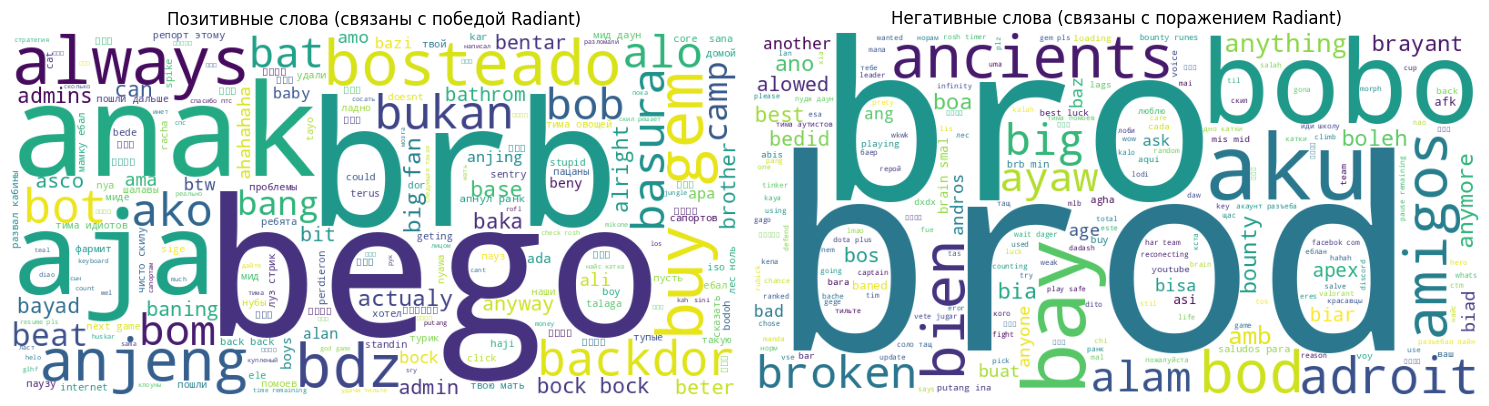

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

feature_names = tfidf.get_feature_names_out()
coef = model.coef_[0]

pos_words = {}
neg_words = {}

for i, word in enumerate(feature_names):
    if coef[i] > 0:
        pos_words[word] = coef[i]
    else:
        neg_words[word] = abs(coef[i])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(pos_words)
axes[0].imshow(wordcloud_pos)
axes[0].set_title('Позитивные слова (связаны с победой Radiant)')
axes[0].axis('off')

wordcloud_neg = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(neg_words)
axes[1].imshow(wordcloud_neg)
axes[1].set_title('Негативные слова (связаны с поражением Radiant)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

ХАХАХ смешные таблички, бро)
ХАХАХ бай гем говорит, это оч смешно аххаха
АХАХАХ РЕПОРТ ЭТОМУ ХАХАХАА
это вообще до бесконечности можно изучать
Забавы дало, значит, графики качественные

<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** что думаете? Сейчас и вообще по модели — негативные получились слова или так, едва?

**Ответ:** Ну в позитивных словах нельзя не заметить слова пацаны и ребята - прямой показатель сплочённости команды. Также там есть слово хускар, вероятно, герой противоположной команды, который сильный в мидгейме, поэтому его и обсуждают, но очень слабый в лейте, а как мы знаем на лоу птс (а это основно ммр) все игры затягиваются до лейта. Видим слово фармит, вероятно, про керри команды рэдиант, сказано скорее всего в негативном ключе, но все мы понимаем, что в конечном итоге это приводит к победе. Видим слово ладно - признак смиренности и последующей победы. Видим купи гем - это очень хороший показатель, человек понимает, что вообще в игре делать. Вообщем, покупка гема - всегда хорошо. Ей богу я бы до конца жизни это анализировала, очень забавно. Но вот основные вещи

Перейдём к картинке с поражениями. Видим слова брокен и иди в школу - явно нездоровая атмосфера в команде. Видим реконектинг - значит, проблемы с подключением, явно ведёт к лузую. Видим age - скорее всего в контексте того, как они спорят и 30 - летний хвастается тем, что родился на 10 лет раньше опонента (базовая ситуация). Также видим слово ютуб - это очень интересно и логично. Слово ютуб почти всегда упоминается в контексте "парни, я смотрел на ютубе гайд на мидовую дровку, щас победим" - это приводит к лузу в 99 случаях из 100.

</div>

### **Часть 5. Агрегации** (1.75 балла) <img align="center" src="https://static.wikia.nocookie.net/dota2_gamepedia/images/4/4a/Techies_emoticon.gif/revision/latest?cb=20180504014918">

В которой студент начинает ведать

#### 📈 **Задание 5.1. Статистики матча** (0.75 балла)

Есть у нас в данных большой кусок про advantage — преимущество команды сил Света с точностью до минуты, по золоту и опыту, всё так же **в пределах 15 минут**. Лежат они в `dota_adv.csv`. Чем больше число, тем больше шанс на победу — всё просто. Только график, как правило, не линеен.

С ними в очередной раз есть *нюансы* — необходимо разобраться, как они там лежат, и всё ли там в порядке со значениями, но это меньшая из проблем. А также нарисовать парочку advantage, чтобы было понимание, как они себя ведут

In [ ]:
adv = pd.read_csv('dota_adv.csv')

Вообщем, для начала парсим - приводим просто к списку чисел каждую строку.

In [ ]:
def parse_adv_array(x):
    if pd.isna(x) or x == '[]' or x == '':
        return []
    try:
        if isinstance(x, str):
            x = x.strip()
            if x.startswith('[') and x.endswith(']'):
                return [float(i) for i in x[1:-1].split() if i.strip()]
        return []
    except:
        return []

adv['radiant_gold_adv'] = adv['radiant_gold_adv'].apply(parse_adv_array)
adv['radiant_exp_adv'] = adv['radiant_exp_adv'].apply(parse_adv_array)
adv = adv[adv['radiant_gold_adv'].apply(len) > 0]

#Здесь мы разворачиваем данные по-минутно, также я вот наны заменяю на значение предыдущей минуты (ну вроде логично весьма)
adv_exploded = adv.explode('radiant_gold_adv').explode('radiant_exp_adv')
adv_exploded['minute'] = adv_exploded.groupby('match_id').cumcount()
adv_exploded['radiant_gold_adv'] = pd.to_numeric(adv_exploded['radiant_gold_adv'], errors='coerce')
adv_exploded['radiant_exp_adv'] = pd.to_numeric(adv_exploded['radiant_exp_adv'], errors='coerce')

adv_exploded['radiant_gold_adv'] = adv_exploded.groupby('match_id')['radiant_gold_adv'].ffill()
adv_exploded['radiant_exp_adv'] = adv_exploded.groupby('match_id')['radiant_exp_adv'].ffill()

adv_exploded = adv_exploded.dropna(subset=['radiant_gold_adv', 'radiant_exp_adv'])

In [ ]:
#это самми статистики - ниже описала, какие выбрала + почему
stats = adv_exploded.groupby('match_id').agg({
    'radiant_gold_adv': ['mean', 'std', 'max', 'min'],
    'radiant_exp_adv': ['mean', 'std', 'max', 'min']
})
stats.columns = ['_'.join(col) for col in stats.columns]
stats = stats.reset_index()

#тут мы разбиваем собственно средние на дайр и рэдиант - там, где отрицательно даём значение дайр, там где положительное - рэдиант
dire_gold_mean = adv_exploded.groupby('match_id')['radiant_gold_adv'].apply(lambda x: x[x < 0].mean()).rename('dire_gold_mean')
dire_exp_mean = adv_exploded.groupby('match_id')['radiant_exp_adv'].apply(lambda x: x[x < 0].mean()).rename('dire_exp_mean')
radiant_gold_mean = adv_exploded.groupby('match_id')['radiant_gold_adv'].apply(lambda x: x[x > 0].mean()).rename('radiant_gold_mean')
radiant_exp_mean = adv_exploded.groupby('match_id')['radiant_exp_adv'].apply(lambda x: x[x > 0].mean()).rename('radiant_exp_mean')

stats = stats.merge(dire_gold_mean, on='match_id', how='left')
stats = stats.merge(dire_exp_mean, on='match_id', how='left')
stats = stats.merge(radiant_gold_mean, on='match_id', how='left')
stats = stats.merge(radiant_exp_mean, on='match_id', how='left')

matches_train = matches_train.merge(stats, on='match_id', how='left')
matches_test = matches_test.merge(stats, on='match_id', how='left')

adv_cols = [col for col in matches_train.columns if 'gold_adv' in col or 'exp_adv' in col or 'radiant_gold' in col or 'radiant_exp' in col]

#здесь заполняем пропуски, ну я выбрала заполнять средним по строке, на самом деле в этой ситуации, как мне кажется, самое лучшее
for col in adv_cols:
    if '_mean' in col:
        matches_train[col] = matches_train[col].fillna(matches_train[col].median())
        matches_test[col] = matches_test[col].fillna(matches_test[col].median())

for col in adv_cols:
    if col.endswith('_max') or col.endswith('_min') or col.endswith('_std'):
        base = col.replace('_max', '_mean').replace('_min', '_mean').replace('_std', '_mean')
        matches_train[col] = matches_train[col].fillna(matches_train[base])
        matches_test[col] = matches_test[col].fillna(matches_test[base])

all_features = list(set(all_features + adv_cols))

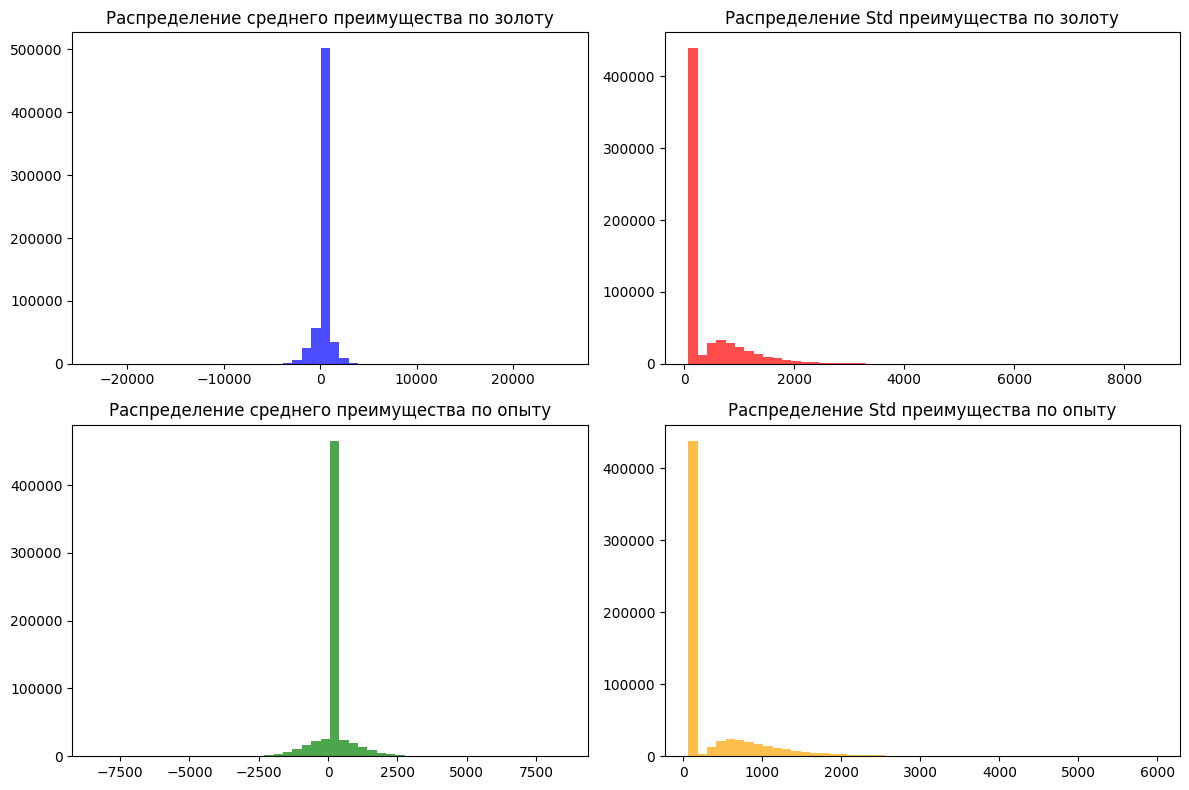

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].hist(matches_train['radiant_gold_adv_mean'], bins=50, color='blue', alpha=0.7)
axes[0,0].set_title('Распределение среднего преимущества по золоту')

axes[0,1].hist(matches_train['radiant_gold_adv_std'], bins=50, color='red', alpha=0.7)
axes[0,1].set_title('Распределение Std преимущества по золоту')

axes[1,0].hist(matches_train['radiant_exp_adv_mean'], bins=50, color='green', alpha=0.7)
axes[1,0].set_title('Распределение среднего преимущества по опыту')

axes[1,1].hist(matches_train['radiant_exp_adv_std'], bins=50, color='orange', alpha=0.7)
axes[1,1].set_title('Распределение Std преимущества по опыту')

plt.tight_layout()
plt.show()

Для начала возьмём простые агрегации. Можете взять те, что вам знакомы (статистики - среднее, стд и др.), можете взять фан факты в вашей любимой библиотеке для данных, например [тут](https://pandas.pydata.org/docs/user_guide/groupby.html#aggregation) или [тут](https://docs.pola.rs/api/python/stable/reference/expressions/aggregation.html).

Задание:
- взять 4 статистики из библиотеки, применить к обеим колонкам `_adv`, <font color="#f68c9d">**обдумать**</font>, почему именно они
- одну из статистику выше разбить по командам, и точно так же примените к колонкам (получится что-то типа `agg_xp` -> `agg_dire_xp`, `agg_radiant_xp`)

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Тут мы встаём на скользкую дорожку переобучения. Агрегаций можно сделать **очень** много. Добавьте их все, и ваша модель превратится в тыкву. Удобнее будет сразу бить их на группы, например `features_last`, `features_q25`, `features_kurtosis_dire_10min+` и так далее, в зависимости от степени упоротости

C другой стороны, агрегации это самая сильная группа фичей, и для десяточки лучше целиться именно в них

</div>

<div style="border-left: 5px solid #f68c9d; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** какие агрегации берём?

**Ответ:** так ну мы взяли средние по экспе и голде - разбили их на дайр и рэдиант (ну я там писала уже, что отрицательное у рэдиант - значит значение идёт в дайр, иначе - в рэдиант). Ну это базовые статистики, очевидно, что полезно. Также вводим максимальное и минимальное значени по голде и экспе - ну это логично тк если был у команды лид в 60 тысяч, то даже если он потом чуть подупал, то ну уж очень вряд ли, что команда проиграет, ну аналогично с минимумом - если проигрывает 60 тысяч голды, то ну удачи выиграть хех). Ещё важный + прикольный эдвантаджес - это стд - по сути корень дисперсии, то есть мы смотрим как сильно отклонялось от среднего. Если средний большой и отклонение маленькое на протяжении 15 минут, то значит, что команда зафиксировала преимущество, на 15 минут это нормально, но на самом деле большой диф - между лидом в 1000 на первой минуте (это очень круто) и лидом в 1000 на 15-ой минуте - это почти ничто, но это мы уже потом будем смотреть, в любом случае, если команда со, скажем, 5-ой минуты зафиксировала лид в 5 тысяч, то это ну я уже не знаю как противоположной команде выиграть.





</div>

Обучите модель по агрегациям (одной группе или нескольким) + предыдущим фичам. Чтобы получить фулл балл, придётся показать, что хотя бы минимальный импрув есть, относительно бейзлайна

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
X = matches_train[all_features]
y = matches_train['radiant_win']

model = LogisticRegression(max_iter=1000, solver='liblinear')
cv_oot = TimeSeriesSplit(n_splits=5)
scores = []

for fold, (train_idx, val_idx) in enumerate(cv_oot.split(matches_train)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model.fit(X_train, y_train)
    pred = model.predict_proba(X_val)[:, 1]
    scores.append(gini(y_val, pred))
    print(gini(y_val, pred))

print(f"Средний Gini с новыми фичами: {np.mean(scores)}")

0.3795373765970578
0.3866618931593053
0.3780395856459391
0.3835449105330917
0.38821728788596643
Средний Gini с новыми фичами: 0.3832


#### 📈 **Задание 5.2. Тренд** (0.5 балла)

Каждый уважающий себя лудоман знает, что 99% процентов игроков останавливается ровно перед тем, как сорвать джекпот. Так и здесь — если команда с треском проигрывает в первые 15 минут матча, возможно это признак камбека в следующие 50, как знать? Попробуем собрать агрегацию похитрее — она будет обозначать тренд, который есть в графиках преимущества, и если пословица верна, наша модель уловит эту зависимость.

<span style="color:grey"><font size="1">Администрация курса МО-1 категорически против азартных игр, пример приводится сугубо в образовательных целях.</font></span>

<div style="border-left: 5px solid #f68c9d; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** для чего нам вообще тренд? Полезная ли это агрегация?

**Ответ:** тренд это вообще самое что ни на есть полезное. То есть, как я говорила, если лид застыл (то есть и на первой, и на пятнадцатой минуте лид один) - то это значит, что команда уже и не так доминирует и вторая её нагоняет. Тк вес лида на каждой минуте разный - лид в 2000 на третьей минуте - это очень хорошо, но лид в 2000 на 15-ой минуте - это очень мало.

</div>

Агрегировать можно и вещи несколько более прикольные, чем те, что есть в основном функционале. Делать это мы будем, как вы наверняка догадались, трансформером, ну а чем же ещё. Что он умеет?

1. Принимает на вход функцию колонку и <font color="#cb9255">**параметры**</font> на ваш вкус, как минимум `method`, метод расчёта `slope`
2. Выделяет коэффициент наклона (`slope`, он же $\alpha$) при помощи одного из методов:
   - `'delta'`: разность первого и последнего значений $|x_{\max} - x_{\min}|$
   - `'OLS'`: линейная регрессия, обученная методом МНК $(X^TX)^{-1}X^Ty$
   - альтернативный метод, порождённый вашей бурной фантазией
3. Считает `r2` и `intercept` для одного advantage (если что это тоже могут быть наши фичи!)

In [ ]:
from typing import Iterable

class TrendTransformer:

    def __init__(self, columns: Iterable[str]):
        self.columns = columns
        self.slopes_ = {}
        self.intercepts_ = {}
        self.r2_ = {}

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col in self.columns:
            if col not in X.columns:
                continue

            delta = X.groupby('match_id')[col].agg(lambda x: x.iloc[-1] - x.iloc[0])
            delta_dict = delta.to_dict()

            X[f'{col}_slope_delta'] = X['match_id'].map(delta_dict)

        return X

Реализуйте трансформер. Критерий успеха, вновь, качество — фича должна помочь, хотя бы на долю пункта

In [ ]:
trend_transformer = TrendTransformer(columns=['radiant_gold_adv', 'radiant_exp_adv'])

adv_with_trend = trend_transformer.transform(adv_exploded)

trend_features = adv_with_trend.groupby('match_id').first()[['radiant_gold_adv_slope_delta', 'radiant_exp_adv_slope_delta']].reset_index()

matches_train = matches_train.merge(trend_features, on='match_id', how='left')
matches_test = matches_test.merge(trend_features, on='match_id', how='left')

trend_cols = ['radiant_gold_adv_slope_delta', 'radiant_exp_adv_slope_delta']
all_features = list(set(all_features + trend_cols))

#Опять как всегда заполняю наны медианой
for col in trend_cols:
    if col in matches_train.columns:
        matches_train[col] = matches_train[col].fillna(matches_train[col].median())
        matches_test[col] = matches_test[col].fillna(matches_test[col].median())


In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
X = matches_train[all_features]
y = matches_train['radiant_win']

model = LogisticRegression(max_iter=1000, solver='liblinear')
cv_oot = TimeSeriesSplit(n_splits=5)
scores = []

for fold, (train_idx, val_idx) in enumerate(cv_oot.split(matches_train)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model.fit(X_train, y_train)
    pred = model.predict_proba(X_val)[:, 1]
    scores.append(gini(y_val, pred))
    print(gini(y_val, pred))

print(f"Средний Gini с новыми фичами: {np.mean(scores)}")

0.37405000820617174
0.3793537481950442
0.3773161855522027
0.37250268799274044
0.38390249780903507
Средний Gini с новыми фичами: 0.3774


Это вот если брать отдельно тенденция. Тут также +0.07 примерно делается по джинни, то есть как и просили, больше, чем +0.05 от базлайна.
Если что, это просто я не запускала код, который добавляют в таблицу фичи из 5.1, поэтому они тут не учитываются. Можно было, конечно, всё написать в коде, чтобы не учитывать те фичи, но зачем засорять, если можно просто сначала не запустить ячейку и посмотреть без адвантджесов, а потом запустить и посмотреть с адвантаджасами.

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
X = matches_train[all_features]
y = matches_train['radiant_win']

model = LogisticRegression(max_iter=1000, solver='liblinear')
cv_oot = TimeSeriesSplit(n_splits=5)
scores = []

for fold, (train_idx, val_idx) in enumerate(cv_oot.split(matches_train)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model.fit(X_train, y_train)
    pred = model.predict_proba(X_val)[:, 1]
    scores.append(gini(y_val, pred))
    print(gini(y_val, pred))

print(f"Средний Gini с новыми фичами: {np.mean(scores)}")

0.38219614685614567
0.38798062903501207
0.3874647297778231
0.386062757640909
0.394219969024062
Средний Gini с новыми фичами: 0.3876


А это если брать мои адвантаджи + тенденции. Очень хороший результат. Ну и видно, что тенденции + адвантаджи относительно просто адвантадж тоже дали прирост.
Как и просили.

#### **📈 Задание 5.3. Бинаризация** (0.5 балла)

Ровно одну прикольную фишку для числовых признаков мы пока что не рассмотрели — бинаризацию. Если вы до неё уже догадались, то вы — гений, не думали на <font color="cb9255">**МОП**</font>? А если нет, суть такова:

1. Берём отрезок advantage и бьём его на несколько бинов
2. Бины можно использовать, как фичу саму по себе, а можно подсобрать внутри неё агрегации

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Во-первых, ваша модель внезапно становится нелинейной, хоть и кусочной, это полный отвал \
Во-вторых, это простейший пример ансамбля, если бинаризовать таргет (но у нас, увы нет смысла, он дискретный). Нелинейность полезна почему — в первые минуты преимущество не так решает, как в последние. \
В-третьих, это фильтрует шумный сигнал, выбросы то отлетят в соответствующий бин

</div>

Попробуем? Бинаризуйте признаки advantage: занумеруйте их (сделайте категорию) и посчитайте побиновые агрегации

Стоп, это ровно то, что я и имела в виду, когда говорила, что лид на 1-ой и 13-ой минуте - разные вещи, хех)

In [ ]:
bins = [0, 5, 10, 15]
labels = ['early', 'mid', 'late']
adv_exploded['phase'] = pd.cut(adv_exploded['minute'], bins=bins, labels=labels, right=False)

phase_stats = adv_exploded.groupby(['match_id', 'phase'], observed=False).agg({
    'radiant_gold_adv': ['mean', 'std', 'max', 'min'],
    'radiant_exp_adv': ['mean', 'std', 'max', 'min']
}).unstack()

phase_stats.columns = [f'{col[0]}_{col[1]}'.replace('radiant_', '') for col in phase_stats.columns]
phase_stats = phase_stats.reset_index()

matches_train = matches_train.merge(phase_stats, on='match_id', how='left')
matches_test = matches_test.merge(phase_stats, on='match_id', how='left')

phase_cols = [col for col in phase_stats.columns if col != 'match_id']
all_features = list(set(all_features + phase_cols))

for col in phase_cols:
    if col in matches_train.columns:
        matches_train[col] = matches_train[col].fillna(matches_train[col].median())
        matches_test[col] = matches_test[col].fillna(matches_test[col].median())

Добавлено фазовых фичей: 24
['gold_adv_mean', 'gold_adv_mean', 'gold_adv_mean', 'gold_adv_std', 'gold_adv_std', 'gold_adv_std', 'gold_adv_max', 'gold_adv_max', 'gold_adv_max', 'gold_adv_min', 'gold_adv_min', 'gold_adv_min', 'exp_adv_mean', 'exp_adv_mean', 'exp_adv_mean', 'exp_adv_std', 'exp_adv_std', 'exp_adv_std', 'exp_adv_max', 'exp_adv_max', 'exp_adv_max', 'exp_adv_min', 'exp_adv_min', 'exp_adv_min']


In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
X = matches_train[all_features]
y = matches_train['radiant_win']

model = LogisticRegression(max_iter=1000, solver='liblinear')
cv_oot = TimeSeriesSplit(n_splits=5)
scores = []

for fold, (train_idx, val_idx) in enumerate(cv_oot.split(matches_train)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model.fit(X_train, y_train)
    pred = model.predict_proba(X_val)[:, 1]
    scores.append(gini(y_val, pred))
    print(gini(y_val, pred))

print(f"Средний Gini с новыми фичами: {np.mean(scores)}")

Аналогично, относительно базлайна более чем +0.05.

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
X = matches_train[all_features]
y = matches_train['radiant_win']

model = LogisticRegression(max_iter=1000, solver='liblinear')
cv_oot = TimeSeriesSplit(n_splits=5)
scores = []

for fold, (train_idx, val_idx) in enumerate(cv_oot.split(matches_train)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model.fit(X_train, y_train)
    pred = model.predict_proba(X_val)[:, 1]
    scores.append(gini(y_val, pred))
    print(gini(y_val, pred))

print(f"Средний Gini с новыми фичами: {np.mean(scores)}")

0.38723835919750127
0.38875457270893565
0.39015366765820336
0.3917799729876985
0.39112165842143476
Средний Gini с новыми фичами: 0.3898


И относительно предыдущих фич также видим прирост.

Упомяну ещё, что после 5.1 у меня джинни на кагле был 0.36, а в после 5.1 + 5.2 + 5.3 стал 0,38. То есть по 0,01 прирост примерно, волшебный результат. Как и просили приросты есть, всё есть

### **Часть 6. Около ML** (2 балла) <img height=25px width=35px align="center" src="https://media1.tenor.com/m/72ScVNgTGpYAAAAC/kaneki-tokyo-ghoul.gif"></img>

В которой студент жесточайше чиллит после пережитого ужаса

#### **Задание 6.1. Пайплайн** (0.5 балла)

Работать в ноутбуках становится экспоненциально тяжелее по мере разрастания модели. Чтобы немножко упорядочить хаос, вам предлагается засунуть всё в один пайплайн. Критерии:

- функция или класс (может понравиться `ColumnTransformer` и `Pipeline`)
- возможность нажать одну кнопку, чтобы запустить пайплайн, уйти пить пиво и вернуться к уже готовому submission для Kaggle
- возможность передать флаги (какие фичи добавляем) и параметры (если есть разные варианты сбора параметров)
- включает в себя все пункты, к которым вы прикоснулись в рамках домашнего задания

А вот как именно это делать — дело ваше, для себя же стараетесь

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

#### **Задание 6.2. Storage** (0.25 балла)

Вдогоночку можно ещё и создать псевдо-БД, чтобы хранить наши шедевры и не потеряться в тысячах моделек. Давайте вот такую штуку запилим:

- датафрейм или честная БД для версионирования моделей
- для каждой модели есть уникальный идентификатор
- для каждой модели сохраняются её гиперпараметры или параметры всего пайплайна (если вы его сделали)
- для каждой модели хранятся метрики на валидации

Сделайте и продемонстрируйте

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
import datetime

gini_value = np.mean(scores)

new_entry = pd.DataFrame([{
    'id': len(storage),
    'timestamp': datetime.datetime.now(),
    'features': all_features.copy(),
    'params': model.get_params(),
    'gini': gini_value
}])

storage = pd.concat([storage, new_entry], ignore_index=True)
storage.to_csv('model_storage.csv', index=False)

#### **Задание 6.3. CuML** (0.25 балла)

Если вы таки осмелились делать домашку именно на Kaggle, то поздравляю, пожалуй, это самое здравое решение в этой дз. Чтобы использовать его возможности по полной, пересядьте с вашей модели из `sklearn`, которую вы выбрали в задании про даты **(1.3)**, на модель из `cuml`.

[Разберитесь](https://docs.rapids.ai/api/cuml/stable/), как они используют GPU и проведите тест-драйв на любом наборе фичей

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

#### **Задание 6.4. High tech. Low life** (0.5 балла)

Если вы следите за новостями, то, наверное, заметили появление хайповейших LLM. Злые языки утверждают, что обычному работяге фит предиктору не место в мире будущего, и его заменит ИИ. Давайте в этом (раз)убедимся.

Попробуйте:
1. Спросить у вашей любимой нейросети, какие признаки она может для вас придумать. Можете опираться на пункты выше, можете придумать что-то свое. Но помните, что как говорится, какой стол, такой и стул, поэтому пишите промпты с умом.
2. Показать, что нейросеть вам посоветовала, и реализовать это
3. Проанализировать результат и сделать решительный вывод, хуже ли вы, чем языковая модель.

Попытайтесь либо вспомнить, либо посмотреть, что у нас ещё есть в данных. Там достаточно много полезной информации, которую мы либо совсем никак не брали, либо брали, но поверхностно, либо брали, но можно сделать ещё круче, старые пункты тоже можно доработать

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

#### **Задание 6.5. Отбор признаков** (0.5 балла)

Когда признаков становится так много, что ваша оперативка начинает рыдать, а модель переобучается, как чёрт, поможет только одно средство — отбор фичей!
Это первое и единственное задание, в котором <font color="#cb9255">**выбора**</font> аж три:

<table width="100%" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="33%">
      <font color="#cb9255">Sequential Feature Selector</font>
    </th>
    <th width="33%">
      <font color="#cb9255">Greedy Selection</font>
    </th>
    <th width="33%">
      <font color="#cb9255">Recursive Feature Elimination</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Делаем итеративно. На каждой итерации <br>
      оцениваем важность фичей по их <br>
      импортансу (<code>coef_</code>), берём <br>
      топ‑n худших, выкидываем, go to 0.
    </td>
    <td valign="top">
      Перебираем все комбинации признаков <br>
      и выбираем наилучшую. Звучит тупо, <br>
      но комбинации можно брать по группам <br>
      (например, тексты, агрегации средних <br>
      и т.д.), тогда это не так долго <br>
      <b>(2 часа на 200 признаков)</b>.
    </td>
    <td valign="top">
      Идём с конца и выкидываем по признаку. <br>
      На каждом шаге обучаем по одной модели <br>
      без одного признака (обучаем d‑1 моделей), <br>
      выбираем из них худшую — такой признак <br>
      и устраняем.
    </td>
  </tr>
  <tr>
    <td valign="top">
      Быстро <b>(около 20 минут <br>
      на 200 фичах)</b>, но веса линейной <br>
      регрессии плохо оценивают важность <br>
      фичей; это лучше работает для <br>
      сильных моделей.
    </td>
    <td valign="top">
      Не теряем интеракции. Баланс <br>
      скорость–качество.
    </td>
    <td valign="top">
      Возмутительно долго <b>(10 часов <br>
      на 200 признаков)</b>, но гарантирует <br>
      минимальные потери в качестве.
    </td>
  </tr>
</table>


<div style="border-left: 5px solid #647cb8; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Это улучшит качество, если вы уже страдаете от миллиарда малополезных фичей. Но для получения балла это не нужно, только верный алгоритм

</div>

Сделайте что-нибудь из этого и проанализируйте эффект. Не стесняйтесь модифицировать схему — удалять по несколько фичей за шаг, параллелить и так далее, пункт времязатратный

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

### Заключение и оценивание

Каждая из задач в ноутбуке имеет свою стоимость (указана в скобках рядом с задачей). При этом важно уточнить разницу между баллами за ноутбук и дополнительными баллами за позицию на приватном лидерборде в соревновании на Kaggle:

1. **Максимум за код/ноутбуки — 8.0 баллов.**
   То есть, независимо от суммарной теоретической суммы всех подпунктов в тексте задания, за реализацию в ноутбуке можно получить не более 8 баллов (6 за базу и 2 за продвинутый).

2. **Максимально возможная оценка за всю работу — 13.0 баллов.**
   Остальные до 5.0 баллов начисляются за результаты в соревновании на Kaggle (лидерборд), при выполненном и загруженном в систему Anytask ноутбуке.

Баллы за сореву состоят из трёх частей: трешхолды (до 2 баллов), процентильный бонус (до 2.0 баллов) и бонус за попадание в топ-10 (до 1.0 балла). Суммарный вклад соревнования не может превышать 5.0 баллов.

**A. Процентильный балл (не суммируется):**
* Если вы пробили трешхолд-9 (качество 0.34) — +1 балл.
* Если вы пробили трешхолд-10 (качество 0.36) — +2 балла.

**Б. Процентильный балл:**

* Если вы только прошли трешхолд-10, то баллов вы не получите.
* Если вы обогнали ≥ 10% участников, побивших трешхолд-10 — +0.5 балла.
* Если вы обогнали ≥ 30% участников — +1.0 балла.
* Если вы обогнали ≥ 60% участников — +1.5 балла.
* Если вы обогнали ≥ 90% участников (т.е. попали в топ 10%) — +2.0 балла.

**В. Балл за попадание в топ-10:**

* 1-е место — +1.00 балла
* 2-е–3-е место — +0.75 балла
* 4-е–6-е место — +0.50 балла
* 7-е–10-е место — +0.25 балла

Пример расчёта

* Вы сделали ноутбуки и получили за них 7.0 / 8.0.
* Вы, тем не менее, побили трешхолд-10 → +2.0
* На лидерборде вы, зайка, обогнали 10% участников, побивших трешхолд 10 → процентильный бонус +2.0.
* Ваша позиция — 3-е место → топ-10 бонус +0.75.
* Итого: 7.0 + 2.0 + 2.0 + 0.75 = 11.75.

Можете свериться с картинкой (левая граница не включительно)

<img src="https://i.postimg.cc/nhb25b42/newplot.png" height=720 width=1280>

**Требование к воспроизводимости**

Баллы за соревнование начисляются **только** при наличии пайплайна или ноутбука, который подтверждает результат лучшего сабмита. Такое решение нужно сдавать вместе с базовым и продвинутым ноутбуками и своим ников в kaggle в Anytask ассистенту. Он должен выполнять всё автоматически при запуске ноутбука: при последовательном исполнении всех ячеек ноутбука (без ручных вмешательств) он должен воспроизвести предобработку, обучение/инференс и сгенерировать итоговый CSV-файл с прогнозами, используемый для сабмита.